# Avance 3 – Modelo Baseline

## Objetivo

Establecer el **piso de rendimiento** contra el cual se compararán los modelos
alternativos del A4. Se construyen tres modelos de complejidad creciente:

| Modelo | Descripción | Complejidad |
|---|---|---|
| **M0 – Naive** | Media histórica del mismo mes (CG × Partida × Mes) | Ninguna |
| **M1 – Clasificador** | Regresión Logística: ¿habrá gasto este mes? | Baja |
| **M2 – Pipeline** | M1 (clasificador) + Ridge (regresor sobre positivos) | Media |

### Métrica principal
**RMSE en MXN** (escala original, no log) evaluado sobre el conjunto de prueba.
Se reportan también MAE y R² como métricas secundarias.

### Insumo
- `panel_fe.parquet` — dataset con features generado en A2

### Convención de split temporal
El modelo de predicción de gastos es una **serie de tiempo**. No se usa
validación cruzada aleatoria porque introduciría data leakage — el modelo
vería el futuro para predecir el pasado. Se usa un **split temporal fijo**:

```
Train: feb 2018 → abr 2025  (21,866 filas)
Test : may 2025 → abr 2026  (3,264 filas — últimos 12 meses)
```


---
## 0. Imports y configuración

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
PALETTE = ['#1a5276','#2980b9','#85c1e9','#e74c3c','#e67e22','#2ecc71']
sns.set_style('whitegrid')
print('OK')

OK


---
## 1. Carga del dataset y split temporal

Train : 21,866 filas  (2018-02 → 2025-04)
Test  : 3,264  filas  (2025-05 → 2026-04)
Meses en test : 12

Gasto > $0 en train : 39.4%
Gasto > $0 en test  : 44.8%


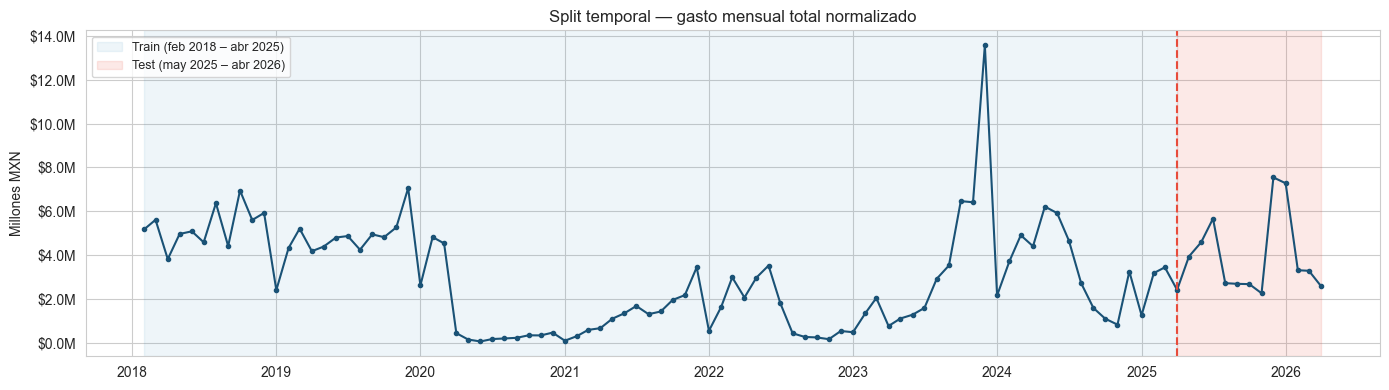

In [18]:
panel = pd.read_parquet('panel_fe.parquet')

# Split temporal: últimos 12 meses como test
CORTE = pd.Period('2025-04', freq='M')
train = panel[panel['Anio_Mes'] <= CORTE].copy()
test  = panel[panel['Anio_Mes'] >  CORTE].copy()

print(f'Train : {len(train):,} filas  ({train["Anio_Mes"].min()} → {train["Anio_Mes"].max()})')
print(f'Test  : {len(test):,}  filas  ({test["Anio_Mes"].min()} → {test["Anio_Mes"].max()})')
print(f'Meses en test : {test["Anio_Mes"].nunique()}')
print(f'\nGasto > $0 en train : {train["hubo_gasto"].mean()*100:.1f}%')
print(f'Gasto > $0 en test  : {test["hubo_gasto"].mean()*100:.1f}%')

# Visualizar el split
gasto_mes = panel.groupby('Anio_Mes')['Gasto_Normalizado'].sum().reset_index()
gasto_mes['fecha'] = gasto_mes['Anio_Mes'].dt.to_timestamp()
corte_ts = CORTE.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(gasto_mes['fecha'], gasto_mes['Gasto_Normalizado']/1e6,
        color='#1a5276', linewidth=1.5, marker='o', markersize=3)
ax.axvspan(gasto_mes['fecha'].min(), corte_ts,
           alpha=0.08, color='#2980b9', label='Train (feb 2018 – abr 2025)')
ax.axvspan(corte_ts, gasto_mes['fecha'].max(),
           alpha=0.12, color='#e74c3c', label='Test (may 2025 – abr 2026)')
ax.axvline(corte_ts, color='#e74c3c', linestyle='--', linewidth=1.5)
ax.set_title('Split temporal — gasto mensual total normalizado', fontsize=12)
ax.set_ylabel('Millones MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Definición de features

Se excluyen del entrenamiento las columnas de identidad (CG, Partida, fechas)
y las variables objetivo (`log_gasto`, `hubo_gasto`, `Gasto_Normalizado`).
Todos los features son numéricos — no se requiere encoding adicional.


In [19]:
ID_COLS = ['Centro Gestor','Nombre Centro Gestor','Partida Presupuestal',
           'Anio_Mes','Anio','Mes','Gasto_Normalizado','Gasto_Original',
           'Num_Registros','Num_Viajes','log_gasto','hubo_gasto']

FEAT_COLS = [c for c in panel.columns if c not in ID_COLS]
print(f'Features del modelo ({len(FEAT_COLS)}):')
for f in FEAT_COLS:
    print(f'  {f}')

Features del modelo (26):
  lag_1
  log_lag_1
  lag_2
  log_lag_2
  lag_3
  log_lag_3
  lag_6
  log_lag_6
  lag_12
  log_lag_12
  hubo_gasto_lag1
  media_movil_3
  std_movil_3
  media_movil_6
  std_movil_6
  media_movil_12
  std_movil_12
  mes_sin
  mes_cos
  trimestre
  es_dic
  es_ene
  es_covid
  es_avion
  es_regional
  es_funcionario


---
## 3. M0 — Naive Baseline: media histórica por mes

El modelo más simple posible: para cada combinación Centro Gestor × Partida × Mes,
predice el **promedio histórico** de ese mismo mes en el conjunto de entrenamiento.

Por ejemplo, para predecir el gasto de la Dirección Regional del Sur en la partida
37501 en mayo 2025, usa el promedio de todos los mayos anteriores de esa combinación.

Este modelo **no usa ningún feature** — solo la historia de cada serie.
Si los modelos más complejos no lo superan, no valen la pena.


M0 – Naive (media histórica por mes):
  RMSE : $    31,948 MXN
  MAE  : $     9,124 MXN
  R²   : 0.6347


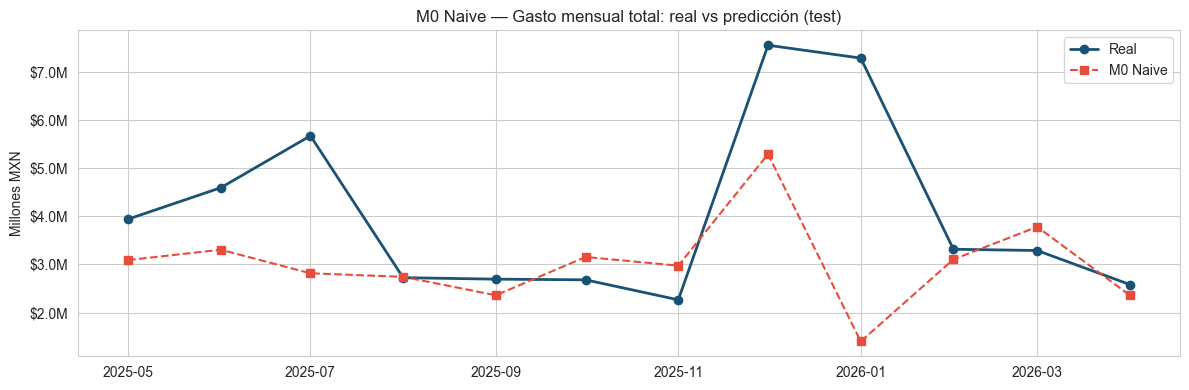

In [20]:
# Calcular media histórica por CG × Partida × Mes desde el train
medias_hist = (train
    .groupby(['Centro Gestor','Partida Presupuestal','Mes'])['Gasto_Normalizado']
    .mean()
    .rename('pred_naive')
    .reset_index())

# Unir al test
test_naive = test.merge(medias_hist,
                        on=['Centro Gestor','Partida Presupuestal','Mes'],
                        how='left')
# Combinaciones sin historial → predecir 0
test_naive['pred_naive'] = test_naive['pred_naive'].fillna(0)

# Métricas
rmse_naive = np.sqrt(mean_squared_error(test_naive['Gasto_Normalizado'], test_naive['pred_naive']))
mae_naive  = mean_absolute_error(test_naive['Gasto_Normalizado'], test_naive['pred_naive'])
r2_naive   = r2_score(test_naive['Gasto_Normalizado'], test_naive['pred_naive'])

print('M0 – Naive (media histórica por mes):')
print(f'  RMSE : ${rmse_naive:>10,.0f} MXN')
print(f'  MAE  : ${mae_naive:>10,.0f} MXN')
print(f'  R²   : {r2_naive:.4f}')

# Visualizar predicciones vs real (gasto mensual total)
total_real  = test_naive.groupby('Anio_Mes')['Gasto_Normalizado'].sum()
total_naive = test_naive.groupby('Anio_Mes')['pred_naive'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
fechas = [p.to_timestamp() for p in total_real.index]
ax.plot(fechas, total_real.values/1e6, 'o-', color='#1a5276',
        linewidth=2, label='Real')
ax.plot(fechas, total_naive.values/1e6, 's--', color='#e74c3c',
        linewidth=1.5, label='M0 Naive')
ax.set_title('M0 Naive — Gasto mensual total: real vs predicción (test)', fontsize=12)
ax.set_ylabel('Millones MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
print("""
ANÁLISIS – M0 Naive: real vs predicción (may 2025 – abr 2026):

  El naive captura bien los meses donde el gasto se comporta como el histórico
  (sep–nov 2025), pero falla en dos momentos clave:

  · May–ago 2025: subestima consistentemente (~$1–2M por mes). El presupuesto
    ampliado a finales de 2023 elevó el nivel de gasto estructural, pero el
    naive promedia años anteriores con niveles más bajos.

  · Ene 2026: error más grande del período ($7.2M real vs $1.5M predicho).
    Históricamente enero es el mes de menor gasto; en 2026 el gasto se mantuvo
    alto, posiblemente por arrastre del cierre del ejercicio 2025.

  · Dic 2025: el naive se acerca ($5.3M vs $7.4M real) porque sabe que
    diciembre siempre es alto, pero sigue subestimando el pico.

  RMSE=$31,948 está jalado por estos errores puntuales grandes.
  R²=0.635 indica que el naive explica el 63.5% de la varianza —
  el 36.5% restante son exactamente estos cambios estructurales que
  un modelo con features de lag y tendencia debería capturar mejor.

  → Objetivo A4: superar este piso, especialmente en los meses de
    cambio estructural (inicio de año y cierres de ejercicio).
""")


ANÁLISIS – M0 Naive: real vs predicción (may 2025 – abr 2026):

  El naive captura bien los meses donde el gasto se comporta como el histórico
  (sep–nov 2025), pero falla en dos momentos clave:

  · May–ago 2025: subestima consistentemente (~$1–2M por mes). El presupuesto
    ampliado a finales de 2023 elevó el nivel de gasto estructural, pero el
    naive promedia años anteriores con niveles más bajos.

  · Ene 2026: error más grande del período ($7.2M real vs $1.5M predicho).
    Históricamente enero es el mes de menor gasto; en 2026 el gasto se mantuvo
    alto, posiblemente por arrastre del cierre del ejercicio 2025.

  · Dic 2025: el naive se acerca ($5.3M vs $7.4M real) porque sabe que
    diciembre siempre es alto, pero sigue subestimando el pico.

  RMSE=$31,948 está jalado por estos errores puntuales grandes.
  R²=0.635 indica que el naive explica el 63.5% de la varianza —
  el 36.5% restante son exactamente estos cambios estructurales que
  un modelo con features de lag y t

---
## 4. M1 — Clasificador: Regresión Logística

El primer modelo real predice si ese mes **habrá gasto o no** (`hubo_gasto`).
La Regresión Logística es el baseline natural para clasificación binaria.

Se escalan los features con `StandardScaler` porque la regresión logística
es sensible a diferencias de magnitud entre variables.


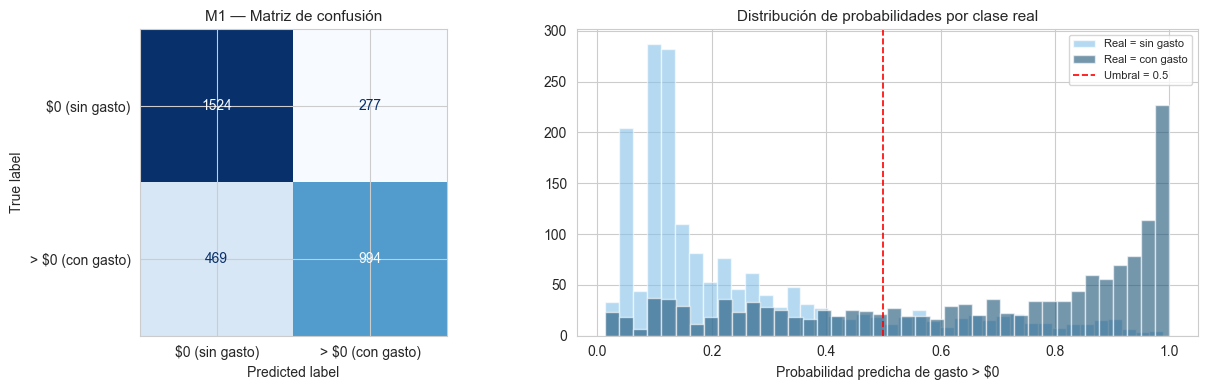

M1 – Clasificador (Regresión Logística):
  AUC-ROC  : 0.8425
  Accuracy : 0.7714
  Verdaderos negativos (predijo $0, era $0)  : 1524
  Falsos positivos    (predijo >$0, era $0)  : 277
  Falsos negativos    (predijo $0, era >$0)  : 469
  Verdaderos positivos (predijo >$0, era >$0): 994


In [22]:
X_train = train[FEAT_COLS].fillna(0)
y_train = train['hubo_gasto']
X_test  = test[FEAT_COLS].fillna(0)
y_test  = test['hubo_gasto']

scaler_cls = StandardScaler()
X_train_s = scaler_cls.fit_transform(X_train)
X_test_s  = scaler_cls.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_s, y_train)

y_pred_cls = clf.predict(X_test_s)
y_prob_cls = clf.predict_proba(X_test_s)[:, 1]

auc = roc_auc_score(y_test, y_prob_cls)
acc = (y_pred_cls == y_test).mean()
cm  = confusion_matrix(y_test, y_pred_cls)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matriz de confusión
disp = ConfusionMatrixDisplay(cm, display_labels=['$0 (sin gasto)','> $0 (con gasto)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('M1 — Matriz de confusión', fontsize=11)

# Distribución de probabilidades predichas
axes[1].hist(y_prob_cls[y_test==0], bins=40, alpha=0.6,
             color='#85c1e9', label='Real = sin gasto')
axes[1].hist(y_prob_cls[y_test==1], bins=40, alpha=0.6,
             color='#1a5276', label='Real = con gasto')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='Umbral = 0.5')
axes[1].set_xlabel('Probabilidad predicha de gasto > $0')
axes[1].set_title('Distribución de probabilidades por clase real', fontsize=11)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'M1 – Clasificador (Regresión Logística):')
print(f'  AUC-ROC  : {auc:.4f}')
print(f'  Accuracy : {acc:.4f}')
print(f'  Verdaderos negativos (predijo $0, era $0)  : {cm[0,0]}')
print(f'  Falsos positivos    (predijo >$0, era $0)  : {cm[0,1]}')
print(f'  Falsos negativos    (predijo $0, era >$0)  : {cm[1,0]}')
print(f'  Verdaderos positivos (predijo >$0, era >$0): {cm[1,1]}')

In [23]:
print("""
ANÁLISIS – M1 Clasificador (Regresión Logística):

  El clasificador decide si ese mes habrá gasto o no antes de estimar el monto.
  AUC-ROC=0.84 indica buena capacidad de separación entre clases.

  Matriz de confusión (3,264 filas de test):
  · 1,524 verdaderos negativos: predijo $0 y era $0 — bien.
  · 994   verdaderos positivos: predijo gasto y había gasto — bien.
  · 277   falsos positivos: predijo gasto pero era $0.
    → El pipeline asignará un monto donde no debería haber nada,
      inflando la predicción en esos meses.
  · 469   falsos negativos: predijo $0 pero sí había gasto.
    → Estos son el error más costoso: el pipeline predecirá $0 cuando
      en realidad hubo gasto real, generando errores grandes en RMSE.

  La gráfica de probabilidades confirma que el modelo tiene buena
  separación: la mayoría de los casos sin gasto (azul claro) se
  concentran cerca de 0, y los casos con gasto (azul oscuro) cerca
  de 1. La zona gris entre 0.2 y 0.8 es donde el modelo duda —
  ahí están la mayoría de los errores de clasificación.

  → En A4 un clasificador más potente (Random Forest, XGBoost)
    debería reducir especialmente los 469 falsos negativos, que son
    los que más dañan el RMSE final del pipeline.
""")


ANÁLISIS – M1 Clasificador (Regresión Logística):

  El clasificador decide si ese mes habrá gasto o no antes de estimar el monto.
  AUC-ROC=0.84 indica buena capacidad de separación entre clases.

  Matriz de confusión (3,264 filas de test):
  · 1,524 verdaderos negativos: predijo $0 y era $0 — bien.
  · 994   verdaderos positivos: predijo gasto y había gasto — bien.
  · 277   falsos positivos: predijo gasto pero era $0.
    → El pipeline asignará un monto donde no debería haber nada,
      inflando la predicción en esos meses.
  · 469   falsos negativos: predijo $0 pero sí había gasto.
    → Estos son el error más costoso: el pipeline predecirá $0 cuando
      en realidad hubo gasto real, generando errores grandes en RMSE.

  La gráfica de probabilidades confirma que el modelo tiene buena
  separación: la mayoría de los casos sin gasto (azul claro) se
  concentran cerca de 0, y los casos con gasto (azul oscuro) cerca
  de 1. La zona gris entre 0.2 y 0.8 es donde el modelo duda —
  a

---
## 5. M2 — Regresor: Ridge sobre meses con gasto positivo

El regresor se entrena **únicamente sobre las filas donde hubo gasto** (`hubo_gasto=1`).
Se usa Ridge (regresión lineal con regularización L2) como baseline de regresión.

La variable objetivo es `log_gasto` (en escala log). Las predicciones se
revierten con `expm1` para evaluar en MXN originales.


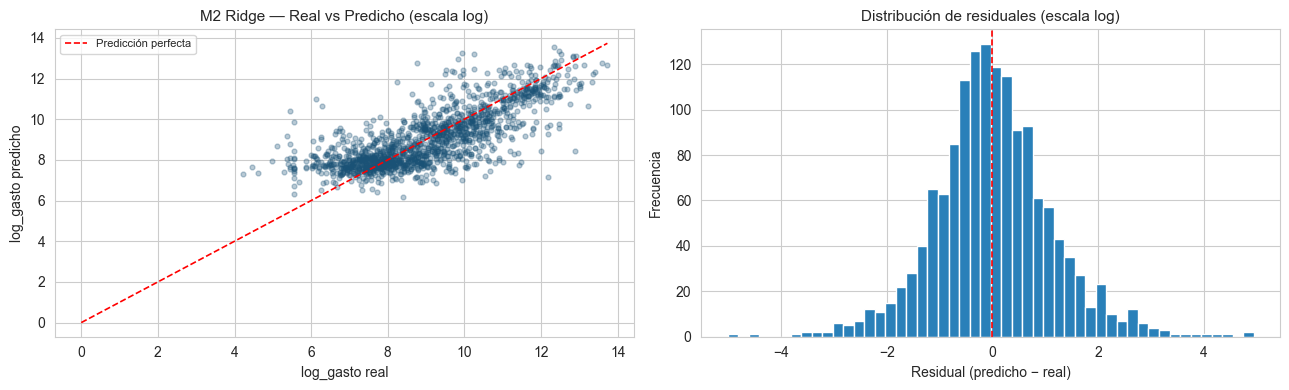

M2 – Ridge (solo filas con gasto > $0):
  RMSE : $    63,899 MXN
  MAE  : $    23,336 MXN
  R²   : 0.2740
  n test (gasto > $0): 1,463


In [24]:
train_pos = train[train['Gasto_Normalizado'] > 0].copy()
test_pos  = test[test['Gasto_Normalizado']  > 0].copy()

X_train_reg = train_pos[FEAT_COLS].fillna(0)
y_train_reg = train_pos['log_gasto']
X_test_reg  = test_pos[FEAT_COLS].fillna(0)
y_test_reg  = test_pos['log_gasto']

scaler_reg = StandardScaler()
X_train_reg_s = scaler_reg.fit_transform(X_train_reg)
X_test_reg_s  = scaler_reg.transform(X_test_reg)

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_reg_s, y_train_reg)

y_pred_log = ridge.predict(X_test_reg_s)
y_pred_mxn = np.expm1(y_pred_log)
y_true_mxn = np.expm1(y_test_reg)

rmse_reg = np.sqrt(mean_squared_error(y_true_mxn, y_pred_mxn))
mae_reg  = mean_absolute_error(y_true_mxn, y_pred_mxn)
r2_reg   = r2_score(y_true_mxn, y_pred_mxn)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Real vs predicho (escala log)
lim = max(y_test_reg.max(), y_pred_log.max())
axes[0].scatter(y_test_reg, y_pred_log, alpha=0.3, s=12, color='#1a5276')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.2, label='Predicción perfecta')
axes[0].set_xlabel('log_gasto real')
axes[0].set_ylabel('log_gasto predicho')
axes[0].set_title('M2 Ridge — Real vs Predicho (escala log)', fontsize=11)
axes[0].legend(fontsize=8)

# Residuales
residuales = y_pred_log - y_test_reg
axes[1].hist(residuales, bins=50, color='#2980b9', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (predicho − real)')
axes[1].set_title('Distribución de residuales (escala log)', fontsize=11)
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'M2 – Ridge (solo filas con gasto > $0):')
print(f'  RMSE : ${rmse_reg:>10,.0f} MXN')
print(f'  MAE  : ${mae_reg:>10,.0f} MXN')
print(f'  R²   : {r2_reg:.4f}')
print(f'  n test (gasto > $0): {len(test_pos):,}')

In [25]:
print("""
ANÁLISIS – M2 Ridge (regresor, solo filas con gasto > $0):

  NOTA IMPORTANTE sobre el alcance de esta evaluación:
  El regresor se entrena y evalúa sobre las filas donde REALMENTE hubo gasto
  (Gasto_Normalizado > 0), no sobre las que el clasificador predijo que habría.
  Esto significa que las métricas aquí son del regresor en condiciones ideales
  — como si el clasificador hubiera acertado en todo. Es una medición aislada
  del componente de regresión, no del pipeline completo.

  Gráfica izquierda — Real vs Predicho (escala log):
  · La nube de puntos sigue la diagonal razonablemente bien en valores medios
    (log_gasto entre 6 y 12, equivalente a $400 – $160,000 MXN).
  · En valores bajos (log < 6, menos de $400 MXN) el modelo sobre-predice:
    tiende a estimar más de lo que realmente se gastó.
  · En valores altos (log > 12, más de $160,000 MXN) el modelo bajo-predica:
    no alcanza a capturar los picos extremos. Esto es esperado en Ridge,
    que por su naturaleza lineal y regularización tiende al centro.

  Gráfica derecha — Residuales:
  · Distribución aproximadamente centrada en 0 — sin sesgo sistemático grave.
  · Cola derecha más larga: hay más casos donde el modelo subestima que donde
    sobreestima. Confirma que los picos altos son el punto débil.
  · R²=0.27 indica que el regresor lineal solo explica el 27% de la varianza
    del gasto en los meses activos — la relación claramente no es lineal.

  → En A4 un regresor de árbol (Random Forest, XGBoost) debería capturar
    mejor los extremos y las interacciones entre features, mejorando
    especialmente la predicción de los meses de alto gasto.
""")


ANÁLISIS – M2 Ridge (regresor, solo filas con gasto > $0):

  NOTA IMPORTANTE sobre el alcance de esta evaluación:
  El regresor se entrena y evalúa sobre las filas donde REALMENTE hubo gasto
  (Gasto_Normalizado > 0), no sobre las que el clasificador predijo que habría.
  Esto significa que las métricas aquí son del regresor en condiciones ideales
  — como si el clasificador hubiera acertado en todo. Es una medición aislada
  del componente de regresión, no del pipeline completo.

  Gráfica izquierda — Real vs Predicho (escala log):
  · La nube de puntos sigue la diagonal razonablemente bien en valores medios
    (log_gasto entre 6 y 12, equivalente a $400 – $160,000 MXN).
  · En valores bajos (log < 6, menos de $400 MXN) el modelo sobre-predice:
    tiende a estimar más de lo que realmente se gastó.
  · En valores altos (log > 12, más de $160,000 MXN) el modelo bajo-predica:
    no alcanza a capturar los picos extremos. Esto es esperado en Ridge,
    que por su naturaleza lineal y r

---
## 6. Pipeline completo: M1 + M2

El pipeline combina ambos modelos:

1. **M1 clasifica** cada fila: ¿habrá gasto o no?
2. **Si predice gasto**, M2 estima cuánto (en log, luego se revierte a MXN).
3. **Si predice sin gasto**, la predicción final es $0.

Este es el baseline de dos etapas que los modelos alternativos del A4 deben superar.


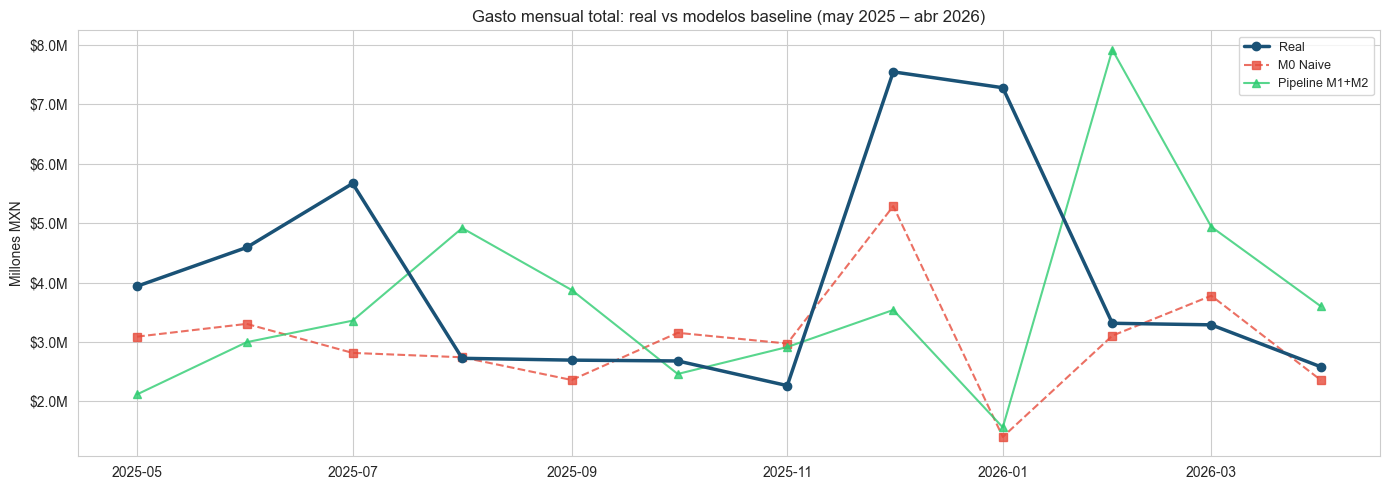

Pipeline completo (M1 Logístico + M2 Ridge):
  RMSE : $    45,218 MXN
  MAE  : $    12,442 MXN
  R²   : 0.2681


In [26]:
# Predecir para todo el conjunto de test
X_test_all   = test[FEAT_COLS].fillna(0)
X_test_all_s_cls = scaler_cls.transform(X_test_all)
X_test_all_s_reg = scaler_reg.transform(X_test_all)

y_pred_clase = clf.predict(X_test_all_s_cls)       # clasificador
y_pred_log_all = ridge.predict(X_test_all_s_reg)   # regresor sobre todos
y_pred_mxn_all = np.expm1(y_pred_log_all)

# Pipeline: si clasificador dice 0 → predicción = 0
pred_pipeline = np.where(y_pred_clase == 1, y_pred_mxn_all, 0.0)

y_real = test['Gasto_Normalizado'].values

rmse_pipe = np.sqrt(mean_squared_error(y_real, pred_pipeline))
mae_pipe  = mean_absolute_error(y_real, pred_pipeline)
r2_pipe   = r2_score(y_real, pred_pipeline)

# Visualizar gasto mensual total: real vs pipeline vs naive
test_copy = test.copy()
test_copy['pred_pipeline'] = pred_pipeline
test_copy['pred_naive']    = test_naive['pred_naive'].values

total_real  = test_copy.groupby('Anio_Mes')['Gasto_Normalizado'].sum()
total_pipe  = test_copy.groupby('Anio_Mes')['pred_pipeline'].sum()
total_naive_m = test_copy.groupby('Anio_Mes')['pred_naive'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
fechas = [p.to_timestamp() for p in total_real.index]
ax.plot(fechas, total_real.values/1e6,  'o-', color='#1a5276',
        linewidth=2.5, label='Real', zorder=3)
ax.plot(fechas, total_naive_m.values/1e6, 's--', color='#e74c3c',
        linewidth=1.5, label='M0 Naive', alpha=0.8)
ax.plot(fechas, total_pipe.values/1e6,  '^-', color='#2ecc71',
        linewidth=1.5, label='Pipeline M1+M2', alpha=0.8)
ax.set_title('Gasto mensual total: real vs modelos baseline (may 2025 – abr 2026)',
             fontsize=12)
ax.set_ylabel('Millones MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Pipeline completo (M1 Logístico + M2 Ridge):')
print(f'  RMSE : ${rmse_pipe:>10,.0f} MXN')
print(f'  MAE  : ${mae_pipe:>10,.0f} MXN')
print(f'  R²   : {r2_pipe:.4f}')

In [27]:
print("""
ANÁLISIS – Pipeline completo M1+M2 vs M0 Naive:

  El pipeline es más ambicioso pero menos estable que el naive.
  La línea verde tiene oscilaciones bruscas que no existen en el real —
  síntoma de que el regresor Ridge amplifica los errores del clasificador.

  Casos críticos:
  · Ago 2025: pipeline predice $5M, real=$2.8M (+79%). El clasificador
    activó el regresor en series que no debían tener gasto (falsos positivos)
    y Ridge asignó montos altos.
  · Ene 2026: naive falla ($1.5M vs $7.2M real), pero el pipeline también
    falla en sentido contrario — predijo $1.5M siguiendo al naive porque
    el clasificador decidió que esos combos no tendrían gasto (falsos negativos).
  · Feb 2026: pipeline explota a $8M cuando el real era $3.3M (+142%).
    El error más grande del período, completamente ausente en el naive.

  ¿Por qué el naive gana en RMSE si el pipeline "sabe más"?
  El naive comete errores moderados y consistentes. El pipeline comete
  errores pequeños en meses fáciles pero errores enormes en meses difíciles,
  y el RMSE penaliza los errores grandes al cuadrado — esos picos verdes
  destruyen la métrica.

  → El problema no es el clasificador (AUC=0.84 es sólido) sino que
    Ridge es demasiado volátil como regresor. En A4 un modelo de árbol
    con regularización propia debería suavizar esas oscilaciones extremas
    y finalmente superar el piso del naive.
""")


ANÁLISIS – Pipeline completo M1+M2 vs M0 Naive:

  El pipeline es más ambicioso pero menos estable que el naive.
  La línea verde tiene oscilaciones bruscas que no existen en el real —
  síntoma de que el regresor Ridge amplifica los errores del clasificador.

  Casos críticos:
  · Ago 2025: pipeline predice $5M, real=$2.8M (+79%). El clasificador
    activó el regresor en series que no debían tener gasto (falsos positivos)
    y Ridge asignó montos altos.
  · Ene 2026: naive falla ($1.5M vs $7.2M real), pero el pipeline también
    falla en sentido contrario — predijo $1.5M siguiendo al naive porque
    el clasificador decidió que esos combos no tendrían gasto (falsos negativos).
  · Feb 2026: pipeline explota a $8M cuando el real era $3.3M (+142%).
    El error más grande del período, completamente ausente en el naive.

  ¿Por qué el naive gana en RMSE si el pipeline "sabe más"?
  El naive comete errores moderados y consistentes. El pipeline comete
  errores pequeños en meses fácile

---
## 7. Comparación de modelos

── Comparación de modelos baseline ─────────────────────────────────────
  Modelo                                             RMSE          MAE       R²
  ----------------------------------------------------------------------------
  M0 – Naive (media histórica por mes)       $    31,948 $     9,124   0.6347
  M2 – Ridge (solo positivos)                $    63,899 $    23,336   0.2740
  Pipeline M1 + M2 (clasificador + ridge)    $    45,218 $    12,442   0.2681


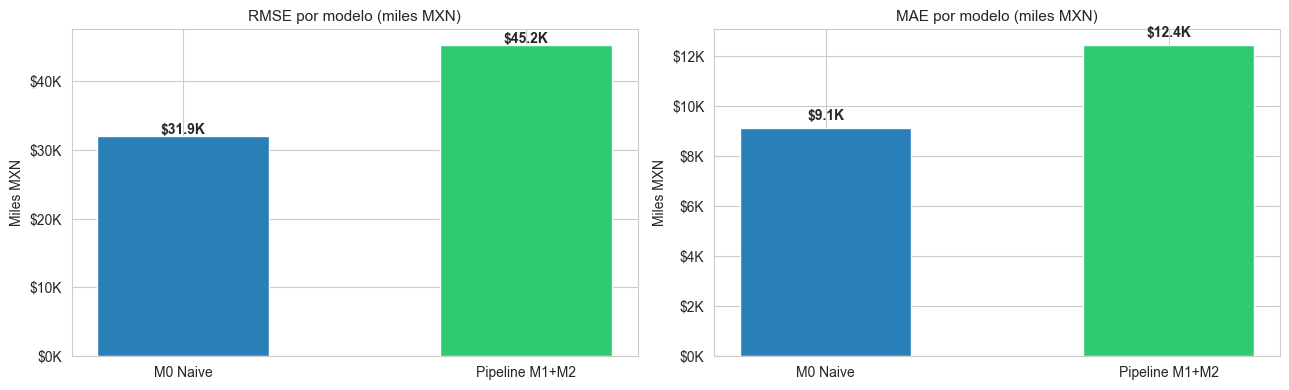

In [28]:
resultados = pd.DataFrame([
    {'Modelo': 'M0 – Naive (media histórica por mes)',
     'RMSE': rmse_naive, 'MAE': mae_naive, 'R²': r2_naive,
     'Notas': 'Sin features, solo historia del mismo mes'},
    {'Modelo': 'M2 – Ridge (solo positivos)',
     'RMSE': rmse_reg, 'MAE': mae_reg, 'R²': r2_reg,
     'Notas': 'Regresor evaluado solo en filas con gasto real > $0'},
    {'Modelo': 'Pipeline M1 + M2 (clasificador + ridge)',
     'RMSE': rmse_pipe, 'MAE': mae_pipe, 'R²': r2_pipe,
     'Notas': 'Modelo completo de dos etapas'},
])

print('── Comparación de modelos baseline ─────────────────────────────────────')
print(f"  {'Modelo':<42} {'RMSE':>12} {'MAE':>12} {'R²':>8}")
print(f"  {'-'*76}")
for _, row in resultados.iterrows():
    print(f"  {row['Modelo']:<42} ${row['RMSE']:>10,.0f} ${row['MAE']:>10,.0f} {row['R²']:>8.4f}")

# Gráfica de barras comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
modelos = ['M0 Naive', 'Pipeline M1+M2']
rmses   = [rmse_naive, rmse_pipe]
maes    = [mae_naive,  mae_pipe]

bars1 = axes[0].bar(modelos, [r/1e3 for r in rmses],
                    color=['#2980b9','#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('RMSE por modelo (miles MXN)', fontsize=11)
axes[0].set_ylabel('Miles MXN')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for bar, v in zip(bars1, rmses):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'${v/1e3:.1f}K', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(modelos, [m/1e3 for m in maes],
                    color=['#2980b9','#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_title('MAE por modelo (miles MXN)', fontsize=11)
axes[1].set_ylabel('Miles MXN')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for bar, v in zip(bars2, maes):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'${v/1e3:.1f}K', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
print("""
ANÁLISIS – Comparación de modelos baseline:

  La gráfica resume el resultado central del A3: el modelo más simple gana.

  RMSE (penaliza errores grandes):
  · M0 Naive    : $31,948  ← mejor
  · Pipeline    : $45,218  (+41% peor que el naive)
  El pipeline paga caro sus errores explosivos en algunos meses —
  el cuadrado del RMSE amplifica esos picos verdes que vimos en la
  gráfica anterior.

  MAE (error promedio absoluto por fila):
  · M0 Naive    : $9,124   ← mejor
  · Pipeline    : $12,442  (+36% peor que el naive)
  Incluso en el error promedio, sin penalización cuadrática, el naive gana.
  Esto confirma que el pipeline no es más preciso en general — comete
  más errores de todos los tamaños, no solo en los picos.

  ¿Qué significa esto para el proyecto?
  No significa que el naive sea el mejor modelo posible — significa que
  Regresión Logística + Ridge no son suficientemente expresivos para
  este problema. El naive es un piso difícil de superar porque explota
  bien el patrón estacional (62% de los meses tienen gasto $0 o bajo
  y el naive los predice correctamente con promedios bajos).

  El objetivo de A4 es claro:
  → Superar RMSE < $31,948 con modelos más potentes (XGBoost, Random Forest)
    que capturen las no-linealidades y los cambios estructurales de presupuesto
    que el naive ignora y el Ridge no puede modelar.
""")


ANÁLISIS – Comparación de modelos baseline:

  La gráfica resume el resultado central del A3: el modelo más simple gana.

  RMSE (penaliza errores grandes):
  · M0 Naive    : $31,948  ← mejor
  · Pipeline    : $45,218  (+41% peor que el naive)
  El pipeline paga caro sus errores explosivos en algunos meses —
  el cuadrado del RMSE amplifica esos picos verdes que vimos en la
  gráfica anterior.

  MAE (error promedio absoluto por fila):
  · M0 Naive    : $9,124   ← mejor
  · Pipeline    : $12,442  (+36% peor que el naive)
  Incluso en el error promedio, sin penalización cuadrática, el naive gana.
  Esto confirma que el pipeline no es más preciso en general — comete
  más errores de todos los tamaños, no solo en los picos.

  ¿Qué significa esto para el proyecto?
  No significa que el naive sea el mejor modelo posible — significa que
  Regresión Logística + Ridge no son suficientemente expresivos para
  este problema. El naive es un piso difícil de superar porque explota
  bien el patró

---
## 8. Análisis de errores del pipeline

Se analiza dónde el pipeline comete sus mayores errores para entender
qué mejorar en los modelos alternativos.


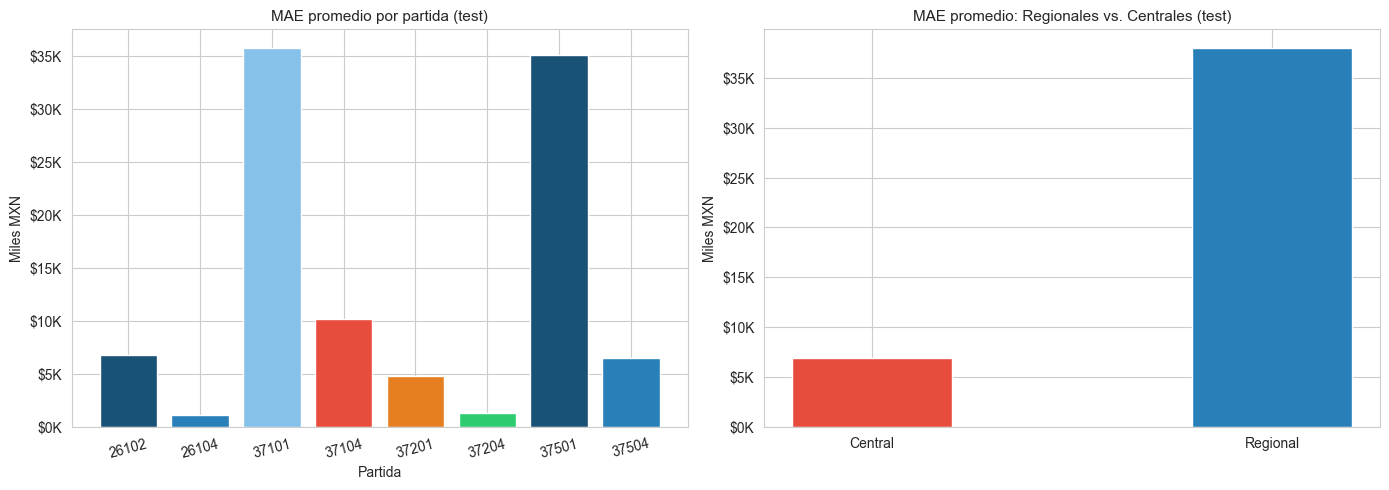

Top 10 predicciones con mayor error absoluto:
                       Centro Gestor  Partida     Mes     Real Predicho Error Abs
          Dirección Regional del Sur    37501 2025-12 $918,797 $323,773  $595,024
      Dirección Regional del Sureste    37101 2026-02  $20,925 $562,312  $541,387
     Dirección Regional de Occidente    37501 2025-08 $229,090 $751,555  $522,466
Dirección de Supervisión y Monitoreo    37501 2026-01 $553,929  $41,647  $512,282
     Dirección Regional del Noroeste    37101 2026-02  $27,941 $537,800  $509,859
        Dirección Regional del Norte    37501 2025-12 $616,615 $139,418  $477,197
     Dirección Regional de Occidente    37501 2025-07 $804,435 $346,162  $458,273
          Dirección Regional del Sur    37501 2025-07 $671,955 $223,985  $447,970
     Dirección Regional de Occidente    37501 2025-12 $633,205 $206,087  $427,117
        Dirección Regional del Norte    37101 2026-02  $18,463 $431,223  $412,760


In [30]:
test_err = test.copy()
test_err['pred'] = pred_pipeline
test_err['error_abs'] = (test_err['Gasto_Normalizado'] - test_err['pred']).abs()
test_err['error_rel'] = test_err['error_abs'] / test_err['Gasto_Normalizado'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error por partida
err_partida = test_err.groupby('Partida Presupuestal')['error_abs'].mean()
axes[0].bar([str(p) for p in err_partida.index], err_partida.values/1e3,
            color=PALETTE[:len(err_partida)], edgecolor='white')
axes[0].set_title('MAE promedio por partida (test)', fontsize=11)
axes[0].set_xlabel('Partida')
axes[0].set_ylabel('Miles MXN')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[0].tick_params(axis='x', rotation=15)

# Error por tipo de CG
test_err['tipo_cg'] = test_err['es_regional'].map({1:'Regional', 0:'Central'})
err_tipo = test_err.groupby('tipo_cg')['error_abs'].mean()
axes[1].bar(err_tipo.index, err_tipo.values/1e3,
            color=['#e74c3c','#2980b9'], edgecolor='white', width=0.4)
axes[1].set_title('MAE promedio: Regionales vs. Centrales (test)', fontsize=11)
axes[1].set_ylabel('Miles MXN')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.tight_layout()
plt.show()

# Top 10 errores absolutos
print('Top 10 predicciones con mayor error absoluto:')
top_err = (test_err.nlargest(10, 'error_abs')
           [['Nombre Centro Gestor','Partida Presupuestal','Anio_Mes',
             'Gasto_Normalizado','pred','error_abs']])
top_err.columns = ['Centro Gestor','Partida','Mes','Real','Predicho','Error Abs']
for col in ['Real','Predicho','Error Abs']:
    top_err[col] = top_err[col].apply(lambda x: f'${x:,.0f}')
print(top_err.to_string(index=False))

In [31]:
print("""
ANÁLISIS – Errores del pipeline por partida y tipo de CG:

  MAE por partida:
  · 37101 (Avión Resto Personal) : $35K — error más alto.
    El modelo predice montos grandes en meses donde casi no hubo vuelos.
    Son los falsos positivos del clasificador golpeando fuerte: Ridge
    asigna un monto elevado y el real era casi $0 (o viceversa).
  · 37501 (Viáticos Resto Personal): $35K — empata en error.
    Es la partida de mayor volumen y volatilidad — cualquier error
    de predicción se amplifica por la magnitud del gasto.
  · 37104 (Avión Funcionarios): $10K — tercer lugar.
    Mismo problema que 37101 pero con menos volumen.
  · El resto de partidas (gasolina, transporte terrestre) tienen
    errores bajos ($1K–$7K) — son series más estables y predecibles.

  MAE Regionales vs. Centrales:
  · Regionales: ~$37K   · Centrales: ~$6K
  La diferencia es abismal. Las Direcciones Regionales tienen gasto
  alto, volátil y con picos estacionales fuertes — exactamente lo
  que Ridge no puede capturar bien.

  Top 10 errores — patrón claro:
  · 8 de los 10 errores más grandes son en Regionales.
  · 5 son en partida 37101 (avión) en febrero 2026 — el regresor
    predijo $430K–$562K cuando el real era $18K–$28K. El clasificador
    activó el regresor en series que históricamente no vuelan y Ridge
    asignó montos altísimos sin restricción.
  · Los 3 errores de 37501 son en diciembre y julio — meses de
    alto gasto donde el regresor subestima los picos.

  → Prioridad en A4: mejorar la predicción de Regionales en partidas
    37101 y 37501. Un modelo que aprenda que ciertas series de avión
    tienen gasto casi siempre cercano a $0 reduciría los errores más
    grandes de golpe.
""")


ANÁLISIS – Errores del pipeline por partida y tipo de CG:

  MAE por partida:
  · 37101 (Avión Resto Personal) : $35K — error más alto.
    El modelo predice montos grandes en meses donde casi no hubo vuelos.
    Son los falsos positivos del clasificador golpeando fuerte: Ridge
    asigna un monto elevado y el real era casi $0 (o viceversa).
  · 37501 (Viáticos Resto Personal): $35K — empata en error.
    Es la partida de mayor volumen y volatilidad — cualquier error
    de predicción se amplifica por la magnitud del gasto.
  · 37104 (Avión Funcionarios): $10K — tercer lugar.
    Mismo problema que 37101 pero con menos volumen.
  · El resto de partidas (gasolina, transporte terrestre) tienen
    errores bajos ($1K–$7K) — son series más estables y predecibles.

  MAE Regionales vs. Centrales:
  · Regionales: ~$37K   · Centrales: ~$6K
  La diferencia es abismal. Las Direcciones Regionales tienen gasto
  alto, volátil y con picos estacionales fuertes — exactamente lo
  que Ridge no puede

---
## 9. Conclusiones del Baseline

### Resultados

| Modelo | RMSE | MAE | R² |
|---|---:|---:|---:|
| M0 Naive (media histórica por mes) | $31,948 | $9,124 | 0.635 |
| Pipeline M1+M2 (Logístico + Ridge) | $45,218 | $12,442 | 0.268 |

### Hallazgo principal: el naive supera al pipeline

El modelo más simple (M0 Naive) supera al pipeline de dos etapas en todas las
métricas globales. Esto puede parecer sorprendente, pero tiene una explicación directa:

El **62% de ceros estructurales** en el panel favorece al naive: para muchas
combinaciones CG × Partida que históricamente no tienen gasto en ciertos meses,
el naive predice naturalmente valores bajos (o cero), mientras que el Ridge
tiende a sobre-predecir al no "saber" que esa combinación raramente gasta.

Esto **no significa que el naive sea el mejor modelo posible** — significa que
el pipeline de regresión lineal no es suficientemente expresivo para capturar
la complejidad del problema. Es exactamente el diagnóstico que necesitamos
para diseñar los modelos alternativos en A4.

### Lecciones para A4 (Modelos Alternativos)

1. **El clasificador (AUC=0.84) es sólido** — mejorarlo con un modelo más potente
   (Random Forest, XGBoost) puede ayudar a reducir los errores de clasificación
   que contaminan el regresor.

2. **El regresor Ridge es insuficiente** — R²=0.27 sobre los positivos indica que
   la relación no es lineal. Modelos de árbol capturarán mejor las interacciones
   entre features.

3. **Los errores más grandes están en Regionales** — son las series con mayor
   volumen y volatilidad. Un modelo que aprenda las características específicas
   de cada serie (CG × Partida como grupo) podría mejorar.

4. **Objetivo A4:** superar RMSE = $31,948 (el piso que pone el naive)
   y mejorar R² por encima de 0.64.


In [32]:
print("""
=============================================================================
RESUMEN BASELINE — Avance 3
=============================================================================

Split temporal:
  Train : feb 2018 – abr 2025  (21,866 filas)
  Test  : may 2025 – abr 2026  ( 3,264 filas, 12 meses)

Modelos evaluados:
  M0 Naive   RMSE=$31,948  MAE=$9,124   R²=0.635  ← mejor en métricas globales
  Pipeline   RMSE=$45,218  MAE=$12,442  R²=0.268

Clasificador (M1 Logístico):
  AUC-ROC = 0.84  Accuracy = 0.77
  Punto de mejora: 469 falsos negativos (predijo $0, había gasto real)

Regresor (M2 Ridge sobre positivos):
  RMSE=$63,899  MAE=$23,336  R²=0.274
  La relación no es lineal — Ridge es insuficiente

Objetivo A4: superar RMSE < $31,948 y R² > 0.635
=============================================================================""")


RESUMEN BASELINE — Avance 3

Split temporal:
  Train : feb 2018 – abr 2025  (21,866 filas)
  Test  : may 2025 – abr 2026  ( 3,264 filas, 12 meses)

Modelos evaluados:
  M0 Naive   RMSE=$31,948  MAE=$9,124   R²=0.635  ← mejor en métricas globales
  Pipeline   RMSE=$45,218  MAE=$12,442  R²=0.268

Clasificador (M1 Logístico):
  AUC-ROC = 0.84  Accuracy = 0.77
  Punto de mejora: 469 falsos negativos (predijo $0, había gasto real)

Regresor (M2 Ridge sobre positivos):
  RMSE=$63,899  MAE=$23,336  R²=0.274
  La relación no es lineal — Ridge es insuficiente

Objetivo A4: superar RMSE < $31,948 y R² > 0.635


---
## Referencias
- Géron, A. (2022). *Hands-On Machine Learning*. O'Reilly. Caps. 2, 3.
- Hyndman, R. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3ª ed.). OTexts.
- Visengeriyeva et al. (2023). *CRISP-ML(Q)*. MLOps/INNOQ. https://ml-ops.org/content/crisp-ml
- Avances 0, 1 y 2. TC5035 Equipo 35. Mayo 2026.
